## Importación de librerías y carga de datos

In [38]:
# Librerías básicas
import pandas as pd
import numpy as np

# Librerías de modelado
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# Librerías métricas
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Cargar datos desde processed
df_data = pd.read_csv('../data/processed/turismo_clima_combinado.csv')

# Vista rápida
df_data.head()


,Zona_Pais,01-2025,02-2025,03-2025,04-2025,05-2025,06-2025,07-2025,08-2025,09-2025,10-2025,11-2025,12-2025,01-2026,02-2026,Total_2025,Total_2026,Total
0,TOTAL,298475.0,293784.0,336476.0,252867.0,205803.0,232571.0,262048.0,199959.0,121815.0,145663.0,247387.0,347143.0,298475.0,293784.0,2943991.0,2943991.0,5887982.0
1,AMERICA DEL NORTE,202581.0,199882.0,247595.0,171151.0,149633.0,177467.0,179300.0,124758.0,69698.0,85817.0,157377.0,234341.0,202581.0,199882.0,1999600.0,1999600.0,3999200.0
2,CANADA,42440.0,39843.0,38851.0,23193.0,11508.0,8996.0,12551.0,10399.0,5144.0,9703.0,28897.0,42556.0,42440.0,39843.0,274081.0,274081.0,548162.0
3,ESTADOS UNIDOS,154170.0,153380.0,200831.0,138949.0,130004.0,161583.0,156348.0,104920.0,57064.0,69581.0,119833.0,181144.0,154170.0,153380.0,1627807.0,1627807.0,3255614.0
4,MEXICO,5971.0,6659.0,7913.0,9009.0,8121.0,6888.0,10401.0,9439.0,7490.0,6533.0,8647.0,10641.0,5971.0,6659.0,97712.0,97712.0,195424.0


## Preparación de los datos

In [39]:
import pandas as pd

# Cargar archivo en un dataframe
df_raw = pd.read_csv('../data/processed/turismo_clima_combinado.csv', sep=',', skip_blank_lines=True)

# Eliminar filas que no contengan nombre de país o etiqueta válida
df_raw = df_raw[df_raw['Zona_Pais'].notna() & (df_raw['Zona_Pais'] != '0')]

# Vista Rapida
df_raw.head()


,Zona_Pais,01-2025,02-2025,03-2025,04-2025,05-2025,06-2025,07-2025,08-2025,09-2025,10-2025,11-2025,12-2025,01-2026,02-2026,Total_2025,Total_2026,Total
0,TOTAL,298475.0,293784.0,336476.0,252867.0,205803.0,232571.0,262048.0,199959.0,121815.0,145663.0,247387.0,347143.0,298475.0,293784.0,2943991.0,2943991.0,5887982.0
1,AMERICA DEL NORTE,202581.0,199882.0,247595.0,171151.0,149633.0,177467.0,179300.0,124758.0,69698.0,85817.0,157377.0,234341.0,202581.0,199882.0,1999600.0,1999600.0,3999200.0
2,CANADA,42440.0,39843.0,38851.0,23193.0,11508.0,8996.0,12551.0,10399.0,5144.0,9703.0,28897.0,42556.0,42440.0,39843.0,274081.0,274081.0,548162.0
3,ESTADOS UNIDOS,154170.0,153380.0,200831.0,138949.0,130004.0,161583.0,156348.0,104920.0,57064.0,69581.0,119833.0,181144.0,154170.0,153380.0,1627807.0,1627807.0,3255614.0
4,MEXICO,5971.0,6659.0,7913.0,9009.0,8121.0,6888.0,10401.0,9439.0,7490.0,6533.0,8647.0,10641.0,5971.0,6659.0,97712.0,97712.0,195424.0


## Separar datos de clima y turistas

In [40]:
df_clima = df_raw[df_raw['Zona_Pais'].isin(['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum'])]
df_turismo = df_raw[~df_raw['Zona_Pais'].isin(['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum'])]

## Vista Rapida
df_turismo.head()



,Zona_Pais,01-2025,02-2025,03-2025,04-2025,05-2025,06-2025,07-2025,08-2025,09-2025,10-2025,11-2025,12-2025,01-2026,02-2026,Total_2025,Total_2026,Total
0,TOTAL,298475.0,293784.0,336476.0,252867.0,205803.0,232571.0,262048.0,199959.0,121815.0,145663.0,247387.0,347143.0,298475.0,293784.0,2943991.0,2943991.0,5887982.0
1,AMERICA DEL NORTE,202581.0,199882.0,247595.0,171151.0,149633.0,177467.0,179300.0,124758.0,69698.0,85817.0,157377.0,234341.0,202581.0,199882.0,1999600.0,1999600.0,3999200.0
2,CANADA,42440.0,39843.0,38851.0,23193.0,11508.0,8996.0,12551.0,10399.0,5144.0,9703.0,28897.0,42556.0,42440.0,39843.0,274081.0,274081.0,548162.0
3,ESTADOS UNIDOS,154170.0,153380.0,200831.0,138949.0,130004.0,161583.0,156348.0,104920.0,57064.0,69581.0,119833.0,181144.0,154170.0,153380.0,1627807.0,1627807.0,3255614.0
4,MEXICO,5971.0,6659.0,7913.0,9009.0,8121.0,6888.0,10401.0,9439.0,7490.0,6533.0,8647.0,10641.0,5971.0,6659.0,97712.0,97712.0,195424.0


In [41]:
# Vista rapida
df_clima.head()

,Zona_Pais,01-2025,02-2025,03-2025,04-2025,05-2025,06-2025,07-2025,08-2025,09-2025,10-2025,11-2025,12-2025,01-2026,02-2026,Total_2025,Total_2026,Total
83,temperature_2m_max,25.229032,25.960714,26.764516,26.116667,25.032258,23.890000,24.635484,24.151613,23.856667,22.629032,23.896667,24.251613,25.061290,24.392857,NaN,NaN,NaN
84,temperature_2m_min,15.412903,15.575000,15.506452,16.473333,15.858065,15.733333,16.103226,15.212903,15.223333,14.877419,15.500000,14.658065,15.164516,15.878571,NaN,NaN,NaN
85,precipitation_sum,45.600000,67.500000,48.400000,220.600000,466.700000,461.600000,176.900000,314.200000,458.300000,564.700000,281.200000,144.900000,20.400000,35.700000,NaN,NaN,NaN


## Reestructurar datos: convertir columnas de meses a filas

In [42]:
df_turismo_long = df_turismo.melt(id_vars='Zona_Pais', var_name='Mes', value_name='Turistas')
df_clima_long = df_clima.melt(id_vars='Zona_Pais', var_name='Mes', value_name='Valor')

df_turismo_long.head()

,Zona_Pais,Mes,Turistas
0,TOTAL,01-2025,298475.0
1,AMERICA DEL NORTE,01-2025,202581.0
2,CANADA,01-2025,42440.0
3,ESTADOS UNIDOS,01-2025,154170.0
4,MEXICO,01-2025,5971.0


In [43]:
df_clima_long.head()

,Zona_Pais,Mes,Valor
0,temperature_2m_max,01-2025,25.229032
1,temperature_2m_min,01-2025,15.412903
2,precipitation_sum,01-2025,45.600000
3,temperature_2m_max,02-2025,25.960714
4,temperature_2m_min,02-2025,15.575000


### Transpone

In [44]:
df_clima_pivot = df_clima_long.pivot_table(index='Mes', columns='Zona_Pais', values='Valor').reset_index()



### Une, usando mes como referencia

In [56]:
df_merged = df_turismo_long.merge(df_clima_pivot, on='Mes', how='left')




### Combinar la información de clima con turismo, solo meses validos (Revisar)

In [57]:
print(df_merged['Mes'].unique()[:20])


['01-2025' '02-2025' '03-2025' '04-2025' '05-2025' '06-2025' '07-2025'
 '08-2025' '09-2025' '10-2025' '11-2025' '12-2025' '01-2026' '02-2026'
 'Total_2025' 'Total_2026' 'Total']


In [69]:
# Reestructuración y merge de clima + turismo
df_clima_pivot = df_clima_long.pivot_table(index='Mes', columns='Zona_Pais', values='Valor').reset_index()
df_merged = df_turismo_long.merge(df_clima_pivot, on='Mes', how='left')

# 💡 👉 AQUÍ PEGAS EL BLOQUE DE NORMALIZACIÓN 👇
# ------------------------------------------------------------
import pandas as pd

meses_dict = {
    'Ene': '01', 'Feb': '02', 'Mar': '03', 'Abr': '04', 'May': '05', 'Jun': '06',
    'Jul': '07', 'Ago': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dic': '12'
}

df_merged['Mes'] = (df_merged['Mes']
                    .astype(str)
                    .str.strip()
                    .replace(meses_dict, regex=True)
                    .str.replace('_', '-', regex=False)
                    .str.replace(' ', '-', regex=False))

print("Formatos normalizados ejemplos:", df_merged['Mes'].unique()[:10])

df_merged = df_merged[df_merged['Mes'].str.match(r'^\d{1,2}-\d{4}$', na=False)]

df_merged['Año'] = df_merged['Mes'].str[-4:].astype(int)
df_merged['Mes_Num'] = df_merged['Mes'].str.extract(r'^(\d{1,2})').astype(int)

print(df_merged[['Mes', 'Año', 'Mes_Num']].head())
print(f"✅ Registros válidos: {df_merged.shape[0]}")
# ------------------------------------------------------------

# Luego sigues con la preparación para el modelo
features = ['Zona_Pais', 'Mes_Num', 'Año', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum']
df_modelo = df_merged[features + ['Turistas']].copy()

df_modelo = pd.get_dummies(df_modelo, columns=['Zona_Pais'], drop_first=True)
print(f"✅ Dataset del modelo listo: {df_modelo.shape}")
df_modelo.head()


Formatos normalizados ejemplos: ['01-2025' '02-2025' '03-2025' '04-2025' '05-2025' '06-2025' '07-2025'
 '08-2025' '09-2025' '10-2025']
       Mes   Año  Mes_Num
0  01-2025  2025        1
1  01-2025  2025        1
2  01-2025  2025        1
3  01-2025  2025        1
4  01-2025  2025        1
✅ Registros válidos: 1162
✅ Dataset del modelo listo: (1162, 88)


,Mes_Num,Año,temperature_2m_max,temperature_2m_min,precipitation_sum,Turistas,Zona_Pais_AMERICA CENTRAL,Zona_Pais_AMERICA DEL NORTE,Zona_Pais_AMÉRICA DEL SUR,Zona_Pais_ARABIA SAUDITA,...,Zona_Pais_SUDAFRICA,Zona_Pais_SUECIA,Zona_Pais_SUIZA,Zona_Pais_SURINAM,Zona_Pais_TAIWAN,Zona_Pais_TOTAL,Zona_Pais_TRINIDAD Y TOBAGO,Zona_Pais_URUGUAY,Zona_Pais_VENEZUELA,Zona_Pais_ÁFRICA
0,1,2025,25.229032,15.412903,45.6,298475.0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,1,2025,25.229032,15.412903,45.6,202581.0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,2025,25.229032,15.412903,45.6,42440.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,2025,25.229032,15.412903,45.6,154170.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,2025,25.229032,15.412903,45.6,5971.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [52]:
# Mantener solo los meses válidos tipo 'MM-YYYY'
#df_merged = df_merged[df_merged['Mes'].str.match(r'^\d{2}_\d{4}$', na=False)]

##df_merged['Año'] = df_merged['Mes'].str[-4:].astype(int)
#df_merged['Mes_Num'] = df_merged['Mes'].str[:2].astype(int)


In [70]:
df_merged.head()

,Zona_Pais,Mes,Turistas,precipitation_sum,temperature_2m_max,temperature_2m_min,Año,Mes_Num
0,TOTAL,01-2025,298475.0,45.6,25.229032,15.412903,2025,1
1,AMERICA DEL NORTE,01-2025,202581.0,45.6,25.229032,15.412903,2025,1
2,CANADA,01-2025,42440.0,45.6,25.229032,15.412903,2025,1
3,ESTADOS UNIDOS,01-2025,154170.0,45.6,25.229032,15.412903,2025,1
4,MEXICO,01-2025,5971.0,45.6,25.229032,15.412903,2025,1


## Preparar variables para el modelo

In [71]:
# Seleccionar features
features = ['Zona_Pais', 'Mes_Num', 'Año', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum']

df_modelo = df_merged[features + ['Turistas']].copy()

# Variables categóricas → dummies
df_modelo = pd.get_dummies(df_modelo, columns=['Zona_Pais'], drop_first=True)

df_modelo.head()


,Mes_Num,Año,temperature_2m_max,temperature_2m_min,precipitation_sum,Turistas,Zona_Pais_AMERICA CENTRAL,Zona_Pais_AMERICA DEL NORTE,Zona_Pais_AMÉRICA DEL SUR,Zona_Pais_ARABIA SAUDITA,...,Zona_Pais_SUDAFRICA,Zona_Pais_SUECIA,Zona_Pais_SUIZA,Zona_Pais_SURINAM,Zona_Pais_TAIWAN,Zona_Pais_TOTAL,Zona_Pais_TRINIDAD Y TOBAGO,Zona_Pais_URUGUAY,Zona_Pais_VENEZUELA,Zona_Pais_ÁFRICA
0,1,2025,25.229032,15.412903,45.6,298475.0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,1,2025,25.229032,15.412903,45.6,202581.0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,2025,25.229032,15.412903,45.6,42440.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,2025,25.229032,15.412903,45.6,154170.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,2025,25.229032,15.412903,45.6,5971.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Separar datos y correr modelos de regresión - entrenamiento, evaluación y validación

In [72]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Variables
X = df_modelo.drop('Turistas', axis=1)
y = df_modelo['Turistas']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- Modelos ----
# Regresión Lineal
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)
cv_lr = cross_val_score(reg, X_train_scaled, y_train, cv=5)

# KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
cv_rf = cross_val_score(rf, X_train, y_train, cv=5)

# ---- Resultados ----
from sklearn.metrics import mean_squared_error
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'KNN', 'Random Forest'],
    'R2_Test': [
        reg.score(X_test_scaled, y_test),
        knn.score(X_test_scaled, y_test),
        rf.score(X_test, y_test)
    ],
    'RMSE_Test': [
        np.sqrt(mean_squared_error(y_test, reg.predict(X_test_scaled))),
        np.sqrt(mean_squared_error(y_test, knn.predict(X_test_scaled))),
        np.sqrt(mean_squared_error(y_test, rf.predict(X_test)))
    ],
    'CV_Promedio': [np.mean(cv_lr), np.mean(cv_knn), np.mean(cv_rf)]
})

resultados


,Modelo,R2_Test,RMSE_Test,CV_Promedio
0,Regresión Lineal,0.956649,7281.276286,0.890153
1,KNN,0.983325,4515.799483,0.903018
2,Random Forest,0.973756,5665.276105,0.918310


In [ ]:
Graficos comparativos

C:\Users\maortiz\AppData\Local\Temp\ipykernel_34308\1609608416.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R2_Test', data=resultados, palette='viridis')


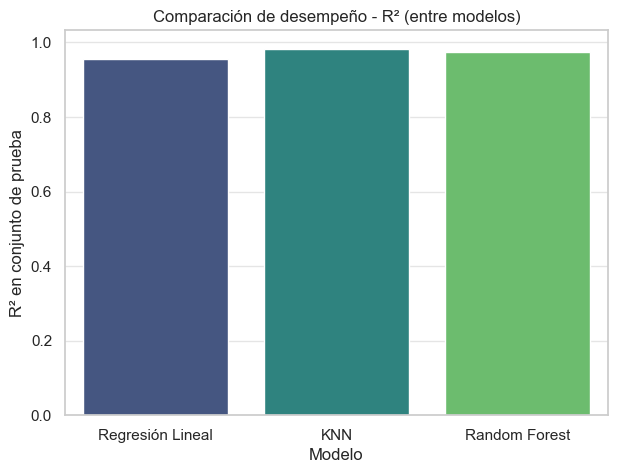

C:\Users\maortiz\AppData\Local\Temp\ipykernel_34308\1609608416.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='RMSE_Test', data=resultados, palette='magma')


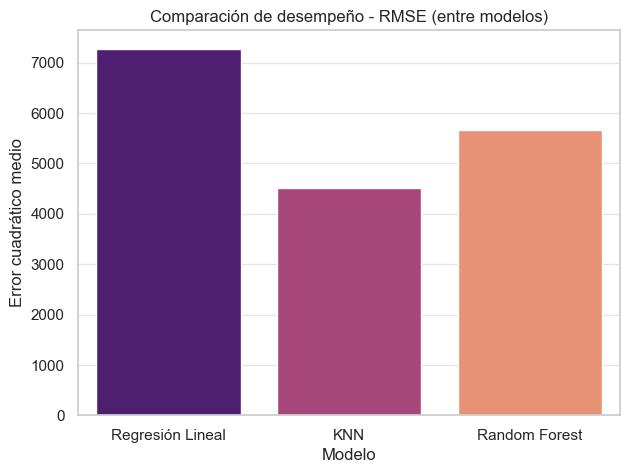

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(7,5))
sns.barplot(x='Modelo', y='R2_Test', data=resultados, palette='viridis')
plt.title('Comparación de desempeño - R² (entre modelos)')
plt.ylabel('R² en conjunto de prueba')
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(x='Modelo', y='RMSE_Test', data=resultados, palette='magma')
plt.title('Comparación de desempeño - RMSE (entre modelos)')
plt.ylabel('Error cuadrático medio')
plt.show()


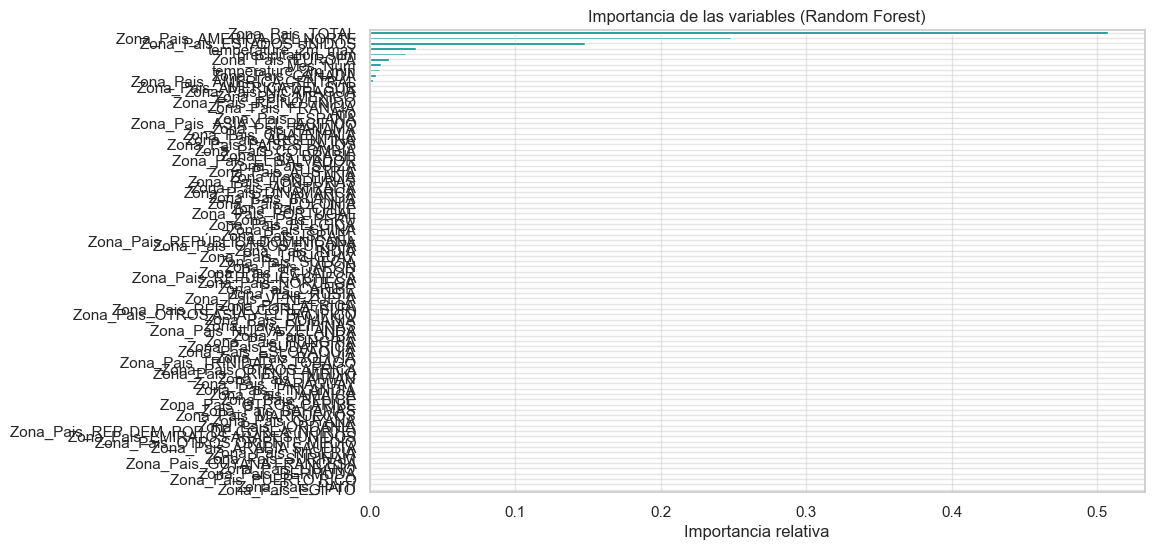

Zona_Pais_AMERICA CENTRAL      0.002549
Zona_Pais_CANADA               0.004201
temperature_2m_min             0.007112
Mes_Num                        0.007857
Zona_Pais_EUROPA               0.013383
precipitation_sum              0.025276
temperature_2m_max             0.032018
Zona_Pais_ESTADOS UNIDOS       0.148042
Zona_Pais_AMERICA DEL NORTE    0.248612
Zona_Pais_TOTAL                0.507300
dtype: float64

In [63]:
# Revisar la importancia de las variables para el modelo Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='darkcyan')
plt.title('Importancia de las variables (Random Forest)')
plt.xlabel('Importancia relativa')
plt.show()

importances.tail(10)


In [ ]:
## # Crear escenarios hipotéticos para marzo–diciembre 2026

In [64]:

zonas_existentes = df_raw['Zona_Pais'].unique()
zonas_existentes = [z for z in zonas_existentes if not z.startswith('temp')]
print("Zonas utilizadas:", zonas_existentes[:5], "...")

# Promedios históricos del clima
clima_promedios = df_modelo[['temperature_2m_max','temperature_2m_min','precipitation_sum']].mean()

# Crear meses futuros
meses_futuros = [f"{str(m).zfill(2)}-2026" for m in range(3,13)]

df_futuro = []
for zona in zonas_existentes:
    for mes in meses_futuros:
        df_futuro.append({
            'Zona_Pais': zona,
            'Mes': mes,
            'Año': 2026,
            'Mes_Num': int(mes[:2]),
            # Escenarios simulados (puedes cambiar los multiplicadores para probar distintas condiciones)
            'temperature_2m_max': clima_promedios['temperature_2m_max'] + np.random.uniform(3, 6),
            'temperature_2m_min': clima_promedios['temperature_2m_min'] + np.random.uniform(1, 3),
            'precipitation_sum': clima_promedios['precipitation_sum'] * np.random.uniform(1.5, 2.5)
        })

df_futuro = pd.DataFrame(df_futuro)
df_futuro = pd.get_dummies(df_futuro, columns=['Zona_Pais'], drop_first=True)
df_futuro.head()


Zonas utilizadas: ['TOTAL', 'AMERICA DEL NORTE', 'CANADA', 'ESTADOS UNIDOS', 'MEXICO'] ...


,Mes,Año,Mes_Num,temperature_2m_max,temperature_2m_min,precipitation_sum,Zona_Pais_AMERICA CENTRAL,Zona_Pais_AMERICA DEL NORTE,Zona_Pais_AMÉRICA DEL SUR,Zona_Pais_ARABIA SAUDITA,...,Zona_Pais_SUECIA,Zona_Pais_SUIZA,Zona_Pais_SURINAM,Zona_Pais_TAIWAN,Zona_Pais_TOTAL,Zona_Pais_TRINIDAD Y TOBAGO,Zona_Pais_URUGUAY,Zona_Pais_VENEZUELA,Zona_Pais_precipitation_sum,Zona_Pais_ÁFRICA
0,03-2026,2026,3,29.481784,18.013718,543.466466,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,04-2026,2026,4,28.521529,16.808244,361.076595,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,05-2026,2026,5,28.428035,18.114230,446.899735,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,06-2026,2026,6,28.600598,17.085696,507.378762,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,07-2026,2026,7,29.652484,17.034734,442.247378,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [65]:
# Asegurar que las columnas coincidan con las del modelo ya entrenado por fallos anteriores
cols_entrenadas = X.columns
for col in cols_entrenadas:
    if col not in df_futuro.columns:
        df_futuro[col] = 0
df_futuro = df_futuro[cols_entrenadas]

# Predicciones
y_futuro_pred = rf.predict(df_futuro)

# Resumen por mes
resultados_futuros = df_futuro.copy()
resultados_futuros['Pred_Turistas'] = y_futuro_pred
resultados_futuros = resultados_futuros[['Mes_Num','Año','Pred_Turistas']].groupby(['Mes_Num','Año']).sum().reset_index()
resultados_futuros['Mes'] = resultados_futuros['Mes_Num'].apply(lambda x: pd.to_datetime(f"{x}-2026", format="%m-%Y"))
resultados_futuros = resultados_futuros.sort_values('Mes')

resultados_futuros


,Mes_Num,Año,Pred_Turistas,Mes
0,3,2026,874934.23,2026-03-01
1,4,2026,881664.79,2026-04-01
2,5,2026,849579.48,2026-05-01
3,6,2026,843114.02,2026-06-01
4,7,2026,845416.21,2026-07-01
5,8,2026,829830.42,2026-08-01
6,9,2026,816233.69,2026-09-01
7,10,2026,825757.68,2026-10-01
8,11,2026,819831.59,2026-11-01
9,12,2026,831640.81,2026-12-01


## Grafico de Resultado

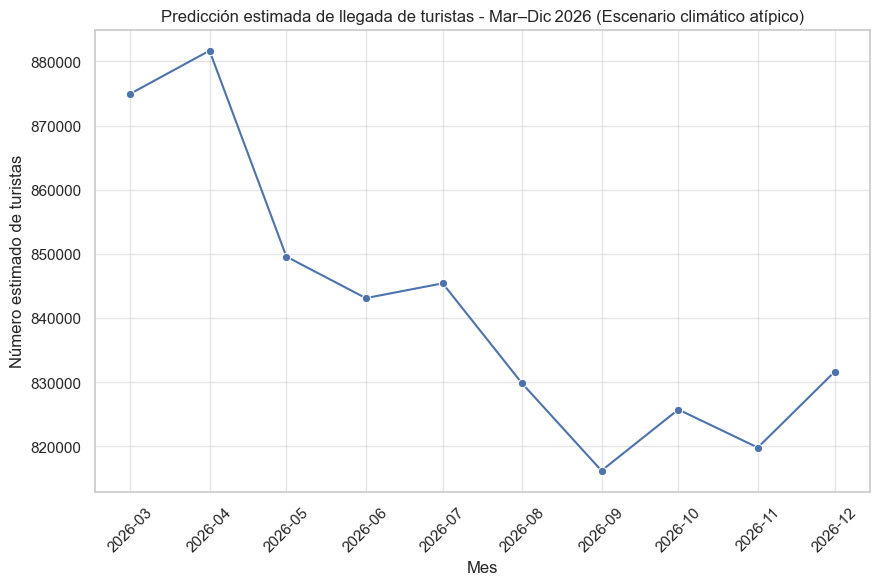

In [66]:
plt.figure(figsize=(10,6))
sns.lineplot(data=resultados_futuros, x='Mes', y='Pred_Turistas', marker='o')
plt.title('Predicción estimada de llegada de turistas - Mar–Dic 2026 (Escenario climático atípico)')
plt.ylabel('Número estimado de turistas')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.show()


In [ ]:
### Cambiando valores de variable clima a mano

In [18]:
factor_precip = 1.0
delta_temp_max = 0


In [19]:
factor_precip = 2.0
delta_temp_max = -1.0


In [20]:
factor_precip = 0.5
delta_temp_max = +2.0


In [21]:
factor_precip = 0.8
delta_temp_max = +4.0


In [73]:
def generar_escenario(df_modelo, df_raw, rf, X,
                      año=2026, mes_inicio=3, mes_fin=12,
                      escenario='normal'):
    zonas_existentes = [z for z in df_raw['Zona_Pais'].unique() if not z.startswith('temp')]
    clima_promedios = df_modelo[['temperature_2m_max','temperature_2m_min','precipitation_sum']].mean()

    # Definir modificadores para distintos escenarios
    escenarios = {
        'normal': {'factor_precip': 1.0, 'delta_temp_max': 0},
        'lluvias_altas': {'factor_precip': 2.0, 'delta_temp_max': -1.0},
        'sequía': {'factor_precip': 0.5, 'delta_temp_max': +2.0},
        'calor_extremo': {'factor_precip': 0.8, 'delta_temp_max': +4.0}
    }

    params = escenarios.get(escenario, escenarios['normal'])
    factor_precip = params['factor_precip']
    delta_temp_max = params['delta_temp_max']

    meses_futuros = [f"{str(m).zfill(2)}-{año}" for m in range(mes_inicio, mes_fin+1)]
    df_futuro = []

    for zona in zonas_existentes:
        for mes in meses_futuros:
            df_futuro.append({
                'Zona_Pais': zona,
                'Mes': mes,
                'Año': año,
                'Mes_Num': int(mes[:2]),
                'temperature_2m_max': clima_promedios['temperature_2m_max'] + np.random.uniform(3, 6) + delta_temp_max,
                'temperature_2m_min': clima_promedios['temperature_2m_min'] + np.random.uniform(1, 3),
                'precipitation_sum': clima_promedios['precipitation_sum'] * np.random.uniform(1.5, 2.5) * factor_precip
            })

    df_futuro = pd.DataFrame(df_futuro)
    df_futuro = pd.get_dummies(df_futuro, columns=['Zona_Pais'], drop_first=True)

    # Asegurar coherencia de columnas
    for col in X.columns:
        if col not in df_futuro.columns:
            df_futuro[col] = 0
    df_futuro = df_futuro[X.columns]

    # Predicciones
    y_pred = rf.predict(df_futuro)
    df_result = df_futuro.copy()
    df_result['Pred_Turistas'] = y_pred
    df_result['Mes_Num'] = df_result['Mes_Num'].astype(int)

    resumen = (df_result.groupby('Mes_Num')['Pred_Turistas']
                          .sum()
                          .reset_index())
    resumen['Año'] = año
    resumen['Escenario'] = escenario
    resumen['Mes'] = resumen['Mes_Num'].apply(lambda x: pd.to_datetime(f"{x}-{año}", format="%m-%Y"))

    return resumen


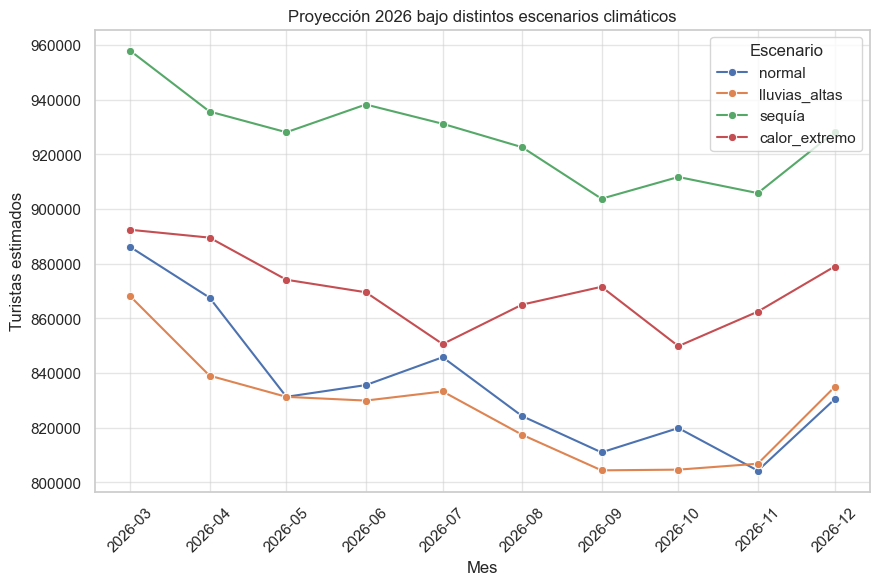

In [76]:
escenarios = ['normal', 'lluvias_altas', 'sequía', 'calor_extremo']
resultados_escenarios = pd.concat(
    [generar_escenario(df_modelo, df_raw, rf, X, escenario=e) for e in escenarios],
    ignore_index=True
)

plt.figure(figsize=(10,6))
sns.lineplot(data=resultados_escenarios, x='Mes', y='Pred_Turistas', hue='Escenario', marker='o')
plt.title('Proyección 2026 bajo distintos escenarios climáticos')
plt.ylabel('Turistas estimados')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.legend(title='Escenario')
plt.show()
